# **Text Classification with TF-IDF and Logistic Regression**

This project builds an end-to-end text classification pipeline for ski resort reviews, using preprocessed customer feedback to train and evaluate a binary sentiment classification model.

The goal is to classify reviews as positive or negative and demonstrate how customer feedback can be transformed into actionable insights for guest experience analysis.

---

## Dataset Overview

**Source:** OnTheSnow Ski Area Reviews (Kaggle)  
**Input File:** `ski_reviews_binary.csv`  
**Format:** CSV with cleaned review text and binary sentiment labels  

---

## Summary

This notebook uses the cleaned dataset produced in the preprocessing pipeline. Each review has already been standardized, lemmatized, and converted into a model-ready text format.

The classification task uses two sentiment labels:

- `1` = positive sentiment, ratings ≥ 3  
- `0` = negative sentiment, ratings < 3  

This approach treats 3-star reviews as neutral-to-positive, helping preserve a realistic and balanced view of customer sentiment.

---

## Key Features

**Cleaned Review Text**  
The `cleaned_text` column contains preprocessed review content that is ready for feature extraction.

**Binary Sentiment Label**  
The `label` column identifies whether each review is classified as positive or negative.

**TF-IDF Features**  
Cleaned text is converted into numerical features using TF-IDF, allowing the model to learn important words and phrases.

**Model Evaluation and Threshold Tuning**  
The notebook evaluates model performance, identifies weaknesses in negative sentiment detection, and adjusts the prediction threshold to better align the model with business needs.

---

## Relevance to This Project

Although the original dataset does not include Batawa Ski Hill reviews, it provides ski-specific language that can be used to build and test a sentiment classification workflow.

A similar model could later be applied to Batawa’s own guest feedback to:

- track customer satisfaction trends  
- identify recurring complaints or service issues  
- surface negative feedback more quickly  
- support data-driven operational and marketing decisions  

## **Step 1: Configuration and Setup**

This step defines the key parameters used throughout the classification pipeline, including the dataset file, feature columns, model settings, and TF-IDF configuration.

Centralizing these values ensures the workflow is reproducible and easy to modify.

In [1]:
# Dataset Settings

# Input dataset (must be available in the Colab environment)
DATASET_FILE = "ski_reviews_binary.csv"

# Text column used as model input
TEXT_COLUMN = "cleaned_text"

# Target label column (binary sentiment)
LABEL_COLUMN = "label"

# Number of classes (binary classification)
NUM_CLASSES = 2


# Model Settings

# Train/test split ratio
TEST_SIZE = 0.2
RANDOM_STATE = 42

# TF-IDF configuration
MAX_FEATURES = 5000   # limit vocabulary size
NGRAM_RANGE = (1, 2)  # unigrams + bigrams


# Logistic Regression Settings

MAX_ITER = 1000

## **Step 2: Environment Setup and Imports**

This step imports the libraries required for data processing, visualization, feature extraction, and model training.

The notebook uses pandas and numpy for data handling, matplotlib and seaborn for visualization, and scikit-learn for TF-IDF vectorization, Logistic Regression, and evaluation metrics.

In [2]:
# Standard Library Imports

import pandas as pd
import numpy as np


# Visualization Imports

import matplotlib.pyplot as plt
import seaborn as sns


# Scikit-Learn Imports

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)


# Display Settings

plt.style.use("default")

## **Step 3: Dataset Loading and Validation**

This step loads the cleaned dataset and verifies that it is ready for modeling.

Key checks include:
- confirming the presence of required columns (`cleaned_text`, `label`)
- removing rows with missing values
- ensuring labels are correctly formatted
- reviewing the class distribution

These checks ensure the model is trained on clean and consistent data.

In [3]:
# Load and Validate Dataset

# Load dataset
df = pd.read_csv(DATASET_FILE)

print(f"Dataset loaded: {DATASET_FILE}")
print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns")

# Preview data
display(df.head())

# Validate required columns
required_columns = [TEXT_COLUMN, LABEL_COLUMN]
missing_columns = [col for col in required_columns if col not in df.columns]

if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}")

# Remove rows with missing text or labels
initial_rows = len(df)
df = df.dropna(subset=required_columns).copy()
rows_removed = initial_rows - len(df)

print(f"Rows removed due to missing values: {rows_removed}")

# Ensure labels are integers
df[LABEL_COLUMN] = df[LABEL_COLUMN].astype(int)

# Class distribution
class_distribution = df[LABEL_COLUMN].value_counts().sort_index()
class_distribution_percent = df[LABEL_COLUMN].value_counts(normalize=True).sort_index() * 100

class_summary = pd.DataFrame({
    "Label": class_distribution.index,
    "Count": class_distribution.values,
    "Percentage": class_distribution_percent.round(2).values
})

display(class_summary)

Dataset loaded: ski_reviews_binary.csv
Shape: 16523 rows, 2 columns


,label,cleaned_text
0,1,glad family experienced squaw wont return next...
1,1,went skiing today granite chief amazing new sn...
2,0,horrible experience family ski vacation plenty...
3,1,squaw alpine incredible terrain impressive sno...
4,1,resort ton exciting diverse advanced terrain b...


Rows removed due to missing values: 0


,Label,Count,Percentage
0,0,2773,16.78
1,1,13750,83.22


## **Step 4: Class Distribution Analysis**

This step examines the balance between positive and negative sentiment labels.

Understanding class distribution is important because imbalanced datasets can bias the model toward the majority class. In this dataset, positive reviews are more common, which is addressed later using class weighting and threshold tuning.

Class distribution:
label
0     2773
1    13750
Name: count, dtype: int64

Number of classes: 2


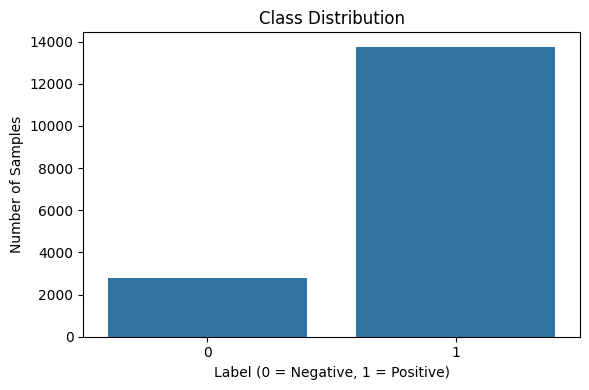

In [4]:
# Class Distribution Analysis

# Count samples per class
class_counts = df[LABEL_COLUMN].value_counts().sort_index()

print("Class distribution:")
print(class_counts)

# Confirm number of classes
num_classes = df[LABEL_COLUMN].nunique()
print(f"\nNumber of classes: {num_classes}")

# Plot class distribution
plt.figure(figsize=(6, 4))
sns.countplot(x=LABEL_COLUMN, data=df)
plt.title("Class Distribution")
plt.xlabel("Label (0 = Negative, 1 = Positive)")
plt.ylabel("Number of Samples")
plt.tight_layout()
plt.show()

### Class Distribution Summary

The dataset contains two sentiment classes used for model training:

- `1` (positive sentiment): ratings ≥ 3  
- `0` (negative sentiment): ratings < 3  

The distribution shows that positive reviews are more common, but there is still a meaningful number of negative reviews for the model to learn from. This provides sufficient representation across both classes while maintaining a realistic reflection of customer feedback.

The visualization above confirms that the dataset is suitable for binary classification. While the classes are not perfectly balanced, the distribution is adequate for training a reliable model.


## **Step 5: Text Preparation**

The review text used in this notebook has already been cleaned and standardized in the preprocessing pipeline.

This step confirms that the data is ready for modeling by:
- ensuring text is stored as strings
- confirming labels are numeric
- defining feature (`X`) and target (`y`) variables

A basic word count check is included to understand the structure of the input data.

In [5]:
# Text Preparation

# Verify required columns are present
required_columns = [TEXT_COLUMN, LABEL_COLUMN]
missing_columns = [col for col in required_columns if col not in df.columns]

if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}")

# Keep only complete rows
df = df.dropna(subset=required_columns).copy()

# Ensure text is stored as string and labels are numeric
df[TEXT_COLUMN] = df[TEXT_COLUMN].astype(str)
df[LABEL_COLUMN] = df[LABEL_COLUMN].astype(int)

# Define features and target
X = df[TEXT_COLUMN]
y = df[LABEL_COLUMN]

# Basic text length check
df["word_count"] = df[TEXT_COLUMN].apply(lambda text: len(text.split()))

text_summary = pd.DataFrame({
    "Metric": [
        "Reviews available",
        "Average word count",
        "Median word count",
        "Minimum word count",
        "Maximum word count"
    ],
    "Value": [
        len(df),
        round(df["word_count"].mean(), 2),
        int(df["word_count"].median()),
        int(df["word_count"].min()),
        int(df["word_count"].max())
    ]
})

display(text_summary)

# Preview model-ready data
display(df[[TEXT_COLUMN, LABEL_COLUMN]].sample(5, random_state=RANDOM_STATE))

,Metric,Value
0,Reviews available,16523.00
1,Average word count,48.48
2,Median word count,39.00
3,Minimum word count,4.00
4,Maximum word count,169.00


,cleaned_text,label
6096,many people think keystone amazing one great d...,1
6834,love snowy range daughter pretty much learned ...,1
6281,skied western montana year choose disco favori...,1
11631,sno mountain problably best mountain pa decent...,0
4533,money not know better snow ever seen terrain e...,1


### Text Preparation Summary

The review text used in this notebook has already been fully preprocessed in a prior pipeline, including cleaning, tokenization, stopword removal, and lemmatization.

The `cleaned_text` column contains standardized and noise-free text, ensuring consistency across all reviews. Labels are correctly formatted as binary values (`0` and `1`), and no missing values remain in the dataset.

Sample reviews confirm that the text remains clear and interpretable after preprocessing. This ensures the model will focus on meaningful language patterns when learning sentiment.


## **Step 6: Exploratory Visualizations**

This step provides quick visual checks to validate the dataset before training.

The visualizations include:
- class distribution to confirm label balance
- review length distribution to understand text variability
- sample reviews to ensure the cleaned text remains meaningful

These checks confirm that the dataset is structured and suitable for modeling.



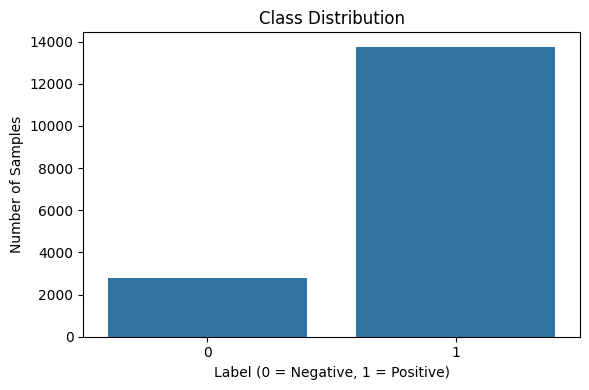

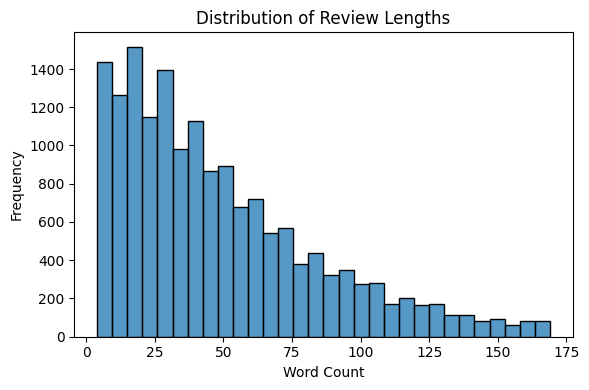

Sample Reviews by Class:

Label 0:
Example 1: silver mountain fun mountain many reason suggest mountain sometimes lift problem always get taken care gondola fun safe wouln not still dangerous save gas terrain park not good schweitzer still fun much offer master perfect family fun suck go lookout something stay fresh powder especially people cannot ride powder plow nice setup thats know umm schweitzer better
Example 2: place great nice close go school time week terrain park improved greatly past two year not many people think know snowboard cannot

Label 1:
Example 1: awesome resort going skiing snowboarding snow always great price great staff friendly looking nightlife disapointed timeshare development nearby offer great accomodations good price backcountry huge never wait line also night skiing
Example 2: great place learn ski ski staff awesome knowledgeable not let progress unless felt confident half day lesson confident tackle mountain train clearly marked made visit florida enjoyab

In [6]:
# Class Distribution Plot

plt.figure(figsize=(6, 4))
sns.countplot(x=LABEL_COLUMN, data=df)
plt.title("Class Distribution")
plt.xlabel("Label (0 = Negative, 1 = Positive)")
plt.ylabel("Number of Samples")
plt.tight_layout()
plt.show()


# Text Length Distribution

plt.figure(figsize=(6, 4))
sns.histplot(df["word_count"], bins=30)
plt.title("Distribution of Review Lengths")
plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


# Sample Reviews by Class

print("Sample Reviews by Class:")

for label in sorted(df[LABEL_COLUMN].unique()):
    print(f"\nLabel {label}:")

    samples = df[df[LABEL_COLUMN] == label]["cleaned_text"]

    # Safe sampling
    samples = samples.sample(min(2, len(samples)), random_state=RANDOM_STATE)

    for i, text in enumerate(samples, 1):
        print(f"Example {i}: {text}")

### Exploratory Visualization Summary

Several visual checks were conducted to validate the dataset before model training.

The class distribution confirms both sentiment classes are represented, while the review length distribution shows a reasonable range of input sizes. Sample reviews demonstrate that the cleaned text remains meaningful and interpretable.

Together, these checks confirm that the dataset is ready for model training.

## **Step 7: Train / Test Split**

This step divides the dataset into training and test sets.

An 80/20 split is used, with stratified sampling to preserve the original class distribution. This ensures the model is trained on representative data and evaluated fairly on unseen reviews.

In [7]:
# Train / Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    stratify=y,
    random_state=RANDOM_STATE
)

print("Data split completed.")
print(f"Training set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")


# Class Distribution Check

def show_distribution(name, labels):
    print(f"\n{name} class distribution:")
    print(labels.value_counts())

show_distribution("Training", y_train)
show_distribution("Test", y_test)

Data split completed.
Training set size: 13218
Test set size: 3305

Training class distribution:
label
1    11000
0     2218
Name: count, dtype: int64

Test class distribution:
label
1    2750
0     555
Name: count, dtype: int64


### Train / Test Split Summary

The dataset was divided into training and test sets using stratified sampling to preserve the original class distribution.

- **Training Set (80%)**: used to train the model  
- **Test Set (20%)**: used to evaluate performance  

Both sets maintain a consistent balance between positive and negative reviews, ensuring that the model is trained and evaluated on representative data.

This approach supports a reliable assessment of how well the model generalizes to unseen customer reviews.


## **Step 8: TF-IDF Vectorization**

This step converts cleaned review text into numerical features using TF-IDF.

TF-IDF assigns higher importance to words that are meaningful within a review but less common across the dataset. This helps the model focus on terms that distinguish sentiment.

Both unigrams and bigrams are used to capture individual words and short phrases. The vectorizer is fit on the training data and applied to the test data to prevent data leakage.

In [8]:
# TF-IDF Vectorization

tfidf = TfidfVectorizer(
    max_features=MAX_FEATURES,
    ngram_range=NGRAM_RANGE
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("TF-IDF vectorization completed.")
print(f"Training feature matrix shape: {X_train_tfidf.shape}")
print(f"Test feature matrix shape: {X_test_tfidf.shape}")
print(f"Number of features: {len(tfidf.get_feature_names_out())}")

TF-IDF vectorization completed.
Training feature matrix shape: (13218, 5000)
Test feature matrix shape: (3305, 5000)
Number of features: 5000


### TF-IDF Vectorization Summary

The cleaned review text was converted into TF-IDF feature vectors using unigrams and bigrams. The vectorizer was fit on the training data and applied to the test data to prevent data leakage.

The resulting feature matrices are ready for model training.

## **Step 9: Model Training**

This step trains a Logistic Regression model using the TF-IDF feature representation.

Logistic Regression is used because it performs well on high-dimensional sparse text data, is computationally efficient, and provides interpretable results.

Class weighting is applied to reduce bias toward the majority class and improve the model’s ability to detect negative sentiment.

In [9]:
# Model Training (Logistic Regression)

model = LogisticRegression(
    max_iter=MAX_ITER,
    class_weight="balanced",
    C=0.5
)

model.fit(X_train_tfidf, y_train)

print("Model training completed.")

Model training completed.


### Model Training Summary

A Logistic Regression model was trained using the TF-IDF feature representation of the review text.

To address class imbalance, class weights were applied during training. This ensures the model does not bias toward the more frequent positive class and improves its ability to detect negative sentiment.

The model learns patterns in word usage associated with each sentiment class, providing a strong and interpretable baseline for classification.

## **Step 10: Model Evaluation**

This step evaluates the trained model on unseen test data.

Performance is measured using accuracy, precision, recall, F1-score, and a confusion matrix. The goal is to assess both overall performance and the model’s ability to correctly identify negative reviews.

In [10]:
# Model Evaluation

y_pred = model.predict(X_test_tfidf)

print("Classification Report:\n")
print(classification_report(y_test, y_pred))

metrics_summary = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score"],
    "Score": [
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        f1_score(y_test, y_pred)
    ]
})

metrics_summary["Score"] = metrics_summary["Score"].round(4)
display(metrics_summary)

Classification Report:

              precision    recall  f1-score   support

           0       0.26      0.50      0.34       555
           1       0.88      0.71      0.79      2750

    accuracy                           0.68      3305
   macro avg       0.57      0.61      0.56      3305
weighted avg       0.77      0.68      0.71      3305



,Metric,Score
0,Accuracy,0.6781
1,Precision,0.8763
2,Recall,0.7138
3,F1 Score,0.7868


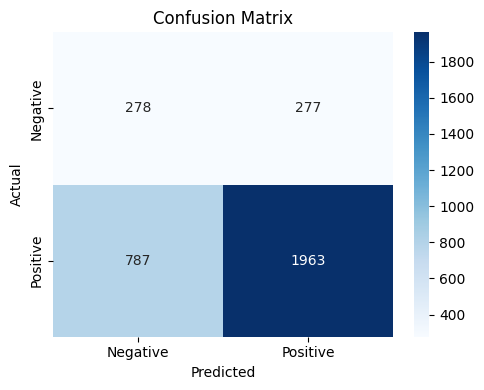

In [11]:
# Confusion Matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"]
)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

### Model Evaluation Summary

The model was evaluated on unseen test data using accuracy, precision, recall, and F1-score.

The results show that the model performs strongly when identifying positive sentiment, which is expected because positive reviews make up the majority of the dataset. However, the model shows low recall for negative sentiment, meaning many negative reviews are misclassified as positive.

This is an important limitation because negative reviews often contain the most actionable feedback for a business. To address this, the next step adjusts the prediction threshold to make the model more cautious before assigning a positive label.

## **Step 11: Threshold Tuning for Business Optimization**

The default classification threshold is 0.50, meaning a review is labeled positive if its predicted probability is at least 50%.

Because positive reviews are more common, the model tends to over-predict positive sentiment. This step increases the threshold to make the model more selective, improving its ability to identify negative reviews.

This adjustment aligns the model with business priorities, where detecting dissatisfied customers is especially important.

In [12]:
# Threshold Tuning

# Get predicted probabilities for the positive class
y_probs = model.predict_proba(X_test_tfidf)[:, 1]

# Test a stricter threshold for positive sentiment
THRESHOLD = 0.60

y_pred_threshold = (y_probs >= THRESHOLD).astype(int)

print(f"Classification Report at Threshold = {THRESHOLD}:\n")
print(classification_report(y_test, y_pred_threshold))

threshold_metrics = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score"],
    "Score": [
        accuracy_score(y_test, y_pred_threshold),
        precision_score(y_test, y_pred_threshold),
        recall_score(y_test, y_pred_threshold),
        f1_score(y_test, y_pred_threshold)
    ]
})

threshold_metrics["Score"] = threshold_metrics["Score"].round(4)
display(threshold_metrics)

Classification Report at Threshold = 0.6:

              precision    recall  f1-score   support

           0       0.21      0.75      0.33       555
           1       0.90      0.44      0.59      2750

    accuracy                           0.49      3305
   macro avg       0.55      0.59      0.46      3305
weighted avg       0.78      0.49      0.55      3305



,Metric,Score
0,Accuracy,0.4914
1,Precision,0.8968
2,Recall,0.4393
3,F1 Score,0.5897


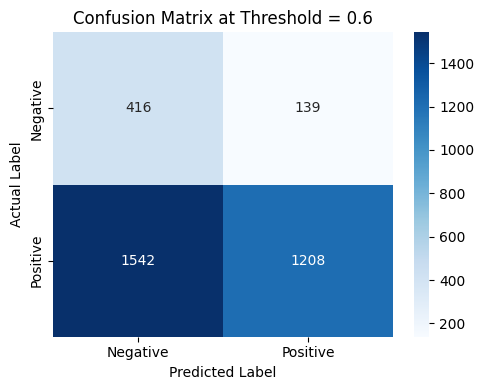

In [13]:
# Confusion Matrix After Threshold Adjustment

cm_threshold = confusion_matrix(y_test, y_pred_threshold)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm_threshold,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"]
)
plt.title(f"Confusion Matrix at Threshold = {THRESHOLD}")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.tight_layout()
plt.show()

### Threshold Tuning Summary

Compared to the default threshold (0.50), increasing the threshold to 0.60 makes the model more selective when predicting positive sentiment. This reduces false positives and improves the model’s ability to correctly identify negative reviews.

This comes at the cost of lower recall for positive sentiment, highlighting the tradeoff between sensitivity and selectivity. However, this tradeoff is valuable in a business context where identifying dissatisfied customers is especially important.

For Batawa Ski Hill, this adjustment makes the model more practical as a tool for flagging reviews that may require attention. More broadly, it demonstrates the importance of tuning model decision thresholds to align with real-world objectives rather than relying solely on default settings.

## **Step 12: Model Interpretation**

This step analyzes the trained model by identifying the words and phrases most strongly associated with each sentiment class.

Logistic Regression coefficients are used to highlight features that contribute to positive and negative predictions. This helps validate that the model is learning meaningful patterns from the data.

In [14]:
# Top Positive and Negative Features

feature_names = tfidf.get_feature_names_out()
coefficients = model.coef_[0]

top_positive_indices = coefficients.argsort()[-15:][::-1]
top_negative_indices = coefficients.argsort()[:15]

top_positive_features = pd.DataFrame({
    "Feature": feature_names[top_positive_indices],
    "Coefficient": coefficients[top_positive_indices].round(4)
})

top_negative_features = pd.DataFrame({
    "Feature": feature_names[top_negative_indices],
    "Coefficient": coefficients[top_negative_indices].round(4)
})

print("Top Positive Features")
display(top_positive_features)

print("Top Negative Features")
display(top_negative_features)

Top Positive Features


,Feature,Coefficient
0,brule,2.6459
1,friendly,1.9654
2,ski brule,1.8942
3,love,1.7933
4,spot,1.6094
5,best,1.4315
6,terrain,1.3931
7,tahoe,1.2813
8,believe,1.2716
9,check,1.2581


Top Negative Features


,Feature,Coefficient
0,rude,-1.5521
1,cannonsburg,-1.4711
2,poorly,-1.4603
3,poor,-1.4122
4,south,-1.3604
5,water,-1.3366
6,inexperienced,-1.2890
7,bad,-1.2152
8,cost,-1.2117
9,skier,-1.1975


### Model Interpretation Summary

The most important features associated with each sentiment class were identified using model coefficients.

Positive sentiment is linked to words describing favorable experiences, while negative sentiment is associated with terms related to poor conditions, service issues, or dissatisfaction.

These results confirm that the model is learning meaningful language patterns rather than random noise, which strengthens confidence in the classification pipeline.

## **Step 13: Predicting Sentiment for New Reviews**

This step applies the trained model to new review text.

A reusable prediction function is created to:
- transform input text using TF-IDF
- generate prediction probabilities
- apply the tuned threshold to assign a sentiment label

This demonstrates how the model can be used in a real-world setting.

In [15]:
# Prediction Function

def predict_sentiment(review_text, threshold=THRESHOLD):
    """
    Predict sentiment for a new review using the selected threshold.
    Returns label, sentiment, and prediction probabilities.
    """
    review_tfidf = tfidf.transform([review_text])
    probability = model.predict_proba(review_tfidf)[0]

    positive_probability = probability[1]
    prediction = 1 if positive_probability >= threshold else 0

    return {
        "review": review_text,
        "predicted_label": int(prediction),
        "sentiment": "Positive" if prediction == 1 else "Negative",
        "negative_probability": round(probability[0], 4),
        "positive_probability": round(probability[1], 4),
        "threshold_used": threshold
    }

In [16]:
# Test sample predictions

sample_reviews = [
    "great snow friendly staff and fun trails",
    "long lines bad service and poor conditions",
    "good mountain but the lifts were slow and crowded",
    "terrible experience long lines rude staff icy conditions not worth the price"
]

for review in sample_reviews:
    display(pd.DataFrame([predict_sentiment(review)]))

,review,predicted_label,sentiment,negative_probability,positive_probability,threshold_used
0,great snow friendly staff and fun trails,1,Positive,0.1494,0.8506,0.6


,review,predicted_label,sentiment,negative_probability,positive_probability,threshold_used
0,long lines bad service and poor conditions,0,Negative,0.8296,0.1704,0.6


,review,predicted_label,sentiment,negative_probability,positive_probability,threshold_used
0,good mountain but the lifts were slow and crowded,0,Negative,0.4176,0.5824,0.6


,review,predicted_label,sentiment,negative_probability,positive_probability,threshold_used
0,terrible experience long lines rude staff icy ...,0,Negative,0.8014,0.1986,0.6


### Prediction Summary

A reusable prediction function was implemented to classify new review text using the tuned prediction threshold.

This allows the model to return both sentiment labels and prediction probabilities, making the output more transparent and useful for real-world decision-making.

Using the adjusted threshold helps the model better flag potentially negative reviews, making it more practical for ongoing sentiment monitoring.

## **Final Summary**

This notebook presents a complete text classification pipeline using preprocessed ski resort reviews.

The workflow includes dataset validation, class distribution analysis, TF-IDF vectorization, Logistic Regression model training, evaluation, threshold tuning, interpretation, and prediction.

Initial results showed strong performance on positive sentiment but weaker detection of negative reviews due to class imbalance. By applying class weighting and threshold tuning, the model becomes more effective at identifying dissatisfied customers.

This project demonstrates how customer feedback can be transformed into structured insights, and highlights that model performance should be evaluated not only by accuracy, but by how well it aligns with real business objectives.